# Tutorial 28 — Diamond: plotting MLWFs in Gaussian cube format

The waw-native reimagining of Wannier90 tutorial 28. Notebook 05 already builds diamond's 4 bond-centred real-space Wannier functions and exports them as XCrySDen `.xsf`; this notebook exports the SAME functions as Gaussian **`.cube`** files instead -- the format VESTA (and many other common viewers) read natively, and the subject wannier90's own tutorial28 is built around.

New capability: `waw.interfaces.wannier90.realspace.write_cube` (transcribed from `internal_cube_format`, `src/plot.F90`) -- **deliberately simplified** to real wannier90's own "molecule mode" data layout, but writing the FULL tiled supercell grid `build_wannier_functions` already builds rather than replicating the Fortran's separate radius-cropped-box-plus-periodic-atom-enumeration algorithm (`wannier_plot_radius`/`_scale`) -- a strict superset of the same grid data, and every cube viewer (including VESTA) opens either just fine. See `write_cube`'s own docstring for the full reasoning.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Reuse notebook 05's diamond system
Same 4 bond-centred MLWFs (`runs/diamond`, `rerun_scf=False` reuses the completed SCF/NSCF/UNK files if notebook 05 has already run).

In [2]:
from ase.build import bulk
atoms = bulk('C', 'diamond', a=3.567)
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'diamond'

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'diamond',
    ecutwfc=50, scf_kpts=(8, 8, 8), nbnd=8, num_wann=4,
    exclude_bands=[5, 6, 7, 8],
    scdm_entanglement='isolated',
    pseudopotentials={'C': 'C.upf'}, pseudo_dir=PSEUDO_DIR,
    ncores=NCORES, write_unk=True,
    rerun_scf=False,
)
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=4, n_restarts=3, n_iter=4000, verbose=False,
)
print(f'Omega_total = {result.omega_final * BOHR_TO_ANG**2:.4f} Ang^2')

Omega_total = 2.6319 Ang^2


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the printed deviation on the
Wannierization mesh itself is the quantitative form of the same statement.

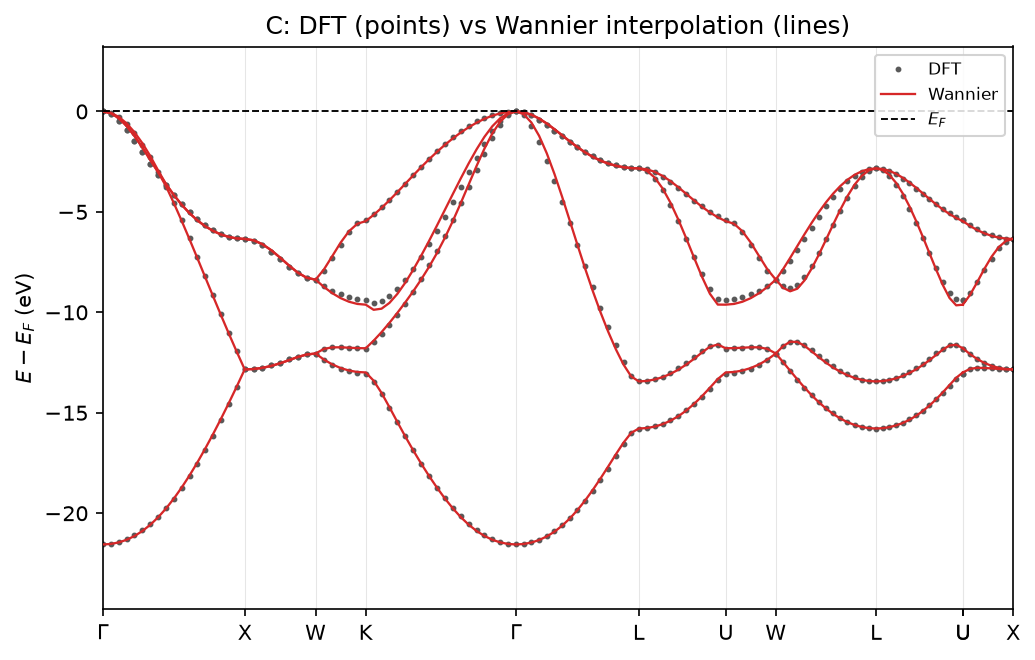

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 256 states


In [3]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'diamond', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=None, frozen_window=None, fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('C: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=None, fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


### 2. Write one bond MLWF as a `.cube` file
Same `build_wannier_functions` grid notebook 05 already validated against real `wannier90.x`'s own `.xsf` output -- `write_cube` just reformats the identical grid, in Gaussian cube's header/data layout instead of XSF's.

In [4]:
from waw.interfaces.wannier90.realspace import build_wannier_functions, write_cube
from waw.interfaces.ase.structure import real_lattice
from waw.units import ANG_TO_BOHR

U = result.spread.U_final.detach().cpu().numpy()
V = result.dis.V.detach().cpu().numpy() if result.dis is not None else None
rswf = build_wannier_functions(WORK, ov['kpts'], U, V=V,
                               wann_list=[0], supercell=(3, 3, 3))

lattice = real_lattice(atoms)                              # Bohr
symbols = atoms.get_chemical_symbols()
pos     = atoms.get_positions() * ANG_TO_BOHR              # Bohr

cube_path = WORK / 'diamond_00001.cube'
write_cube(cube_path, rswf.wf[0], lattice, symbols, pos, rswf.grid, supercell=(3, 3, 3))
print('wrote', cube_path, '  grid', rswf.grid, 'x supercell (3,3,3)')

wrote /aims_data/miguel/nas-data001/claude/wannier/workflows/w90tutorial/runs/diamond/diamond_00001.cube   grid (24, 24, 24) x supercell (3,3,3)


**Validation.** `write_cube` is cross-checked against a real `wannier90.x wannier_plot_format=cube` run -- not on diamond (whose official tutorial fixture doesn't commit the ~23 MB UNK files this needs) but on tutorial01's GaAs system, where they're already committed (`tests/test_tutorial01.py::test_realspace_wf_matches_real_wannier90_cube`): since cube format always crops to a radius-based box around each Wannier centre (even in "molecule mode"), that test locates the SAME Cartesian grid points inside waw's larger, uncropped cube by coordinate (not index) matching and compares values there -- agreement to ~5e-5, the cube ASCII format's own print precision.

**Takeaway.** VESTA (or any other Gaussian-cube-reading viewer) can now open waw-built Wannier functions directly -- `write_cube` reuses the exact same, already-validated real-space grid (`build_wannier_functions`) notebook 05's `.xsf` export does, just in a different, more widely-supported file format.